# Compare deconvolution with and without copy number correction

Levels to think about:
- 10kb
- Per gene
- Per gene promoter

Ideas:
- Copy number correction may affect nucleosome occupancy and promoter occupancy during S-phase, thus we'll have to think about the low hanging fruit to show how copy number correction improves the fit of the chromatin deconvolution.
- At a high-level it should be most clear at the 10kb window.
- Then on the gene-level. The gene level is a bit more challenging because of the different regulation dynamics at play, but it allows us to investigate dosage compensation-type ideas.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [156]:
from pipeline.copy_correction_analysis import CopyCorrectionAnalysis

output_dir = 'output/prototype_pipeline_subset/'
copy_correction_analysis = CopyCorrectionAnalysis(output_dir)


In [3]:
copy_correction_analysis.load_chromosome(chrom=4)

In [194]:
from src.RealDataReplication import load_replication_Fr_df, load_B_df

Fr_df, replication_indices = load_replication_Fr_df(output_dir, chrom)
B, b_df = load_B_df(output_dir, chrom, Fr_df.columns)

In [195]:
b_df

16000      0.887412
18000      1.052220
20000      1.111702
22000      1.124646
24000      1.141570
             ...   
1508000    1.282646
1510000    1.410624
1512000    1.426779
1514000    1.353778
1516000    1.052539
Name: b, Length: 700, dtype: float64

In [196]:
replication_indices

16000      137
18000      137
20000      136
22000      136
24000      135
          ... 
1508000    135
1510000    136
1512000    136
1514000    137
1516000    136
Length: 700, dtype: int64

In [216]:
from src.mnase_10kb_loader import get_bin_for_position

# The copy correction is performed on the 10kb windows, thus a lower resolution
# set of start positions
starts = copy_correction_analysis.chrom_starts

mid_10ks = starts + 5000

row = mid_10ks.iloc[10]
pos_bin_idx, bin_start = get_bin_for_position(row, b_df.index)
row, bin_start


(105000, 100000)

In [205]:
b_df

16000      0.887412
18000      1.052220
20000      1.111702
22000      1.124646
24000      1.141570
             ...   
1508000    1.282646
1510000    1.410624
1512000    1.426779
1514000    1.353778
1516000    1.052539
Name: b, Length: 700, dtype: float64

In [154]:
#def load_means_all_chromosomes():

#for chrom in range(1, 17):
chrom = 4

# copy_correction_analysis.load_chromosome(chrom=chrom)
copy_correction_analysis.load_replication_timing()

def _add_chrom_to_index(dat, chrom):
    cc_means = dat.reset_index()
    cc_means['chr'] = chrom
    cc_means = cc_means.set_index(['chr', 'start'])
    return cc_means

chrom_cc_w_b_means = _add_chrom_to_index(copy_correction_analysis.chrom_b_copy_corrected_means_df, copy_correction_analysis.chrom)
chrom_no_cc_means = _add_chrom_to_index(copy_correction_analysis.chrom_no_cc_means_df, copy_correction_analysis.chrom)
chrom_repl_times = copy_correction_analysis.chrom_replication_times.set_index(['chr', 'start'])

chrom_repl_times

end  replication_index  replication_time
chr start                                                
4   0          10000              137.0         53.155990
    10000      20000              137.0         53.155990
    20000      30000              136.0         51.789134
    30000      40000              134.0         49.055423
    40000      50000              129.0         42.221146
...              ...                ...               ...
    1490000  1500000              134.0         49.055423
    1500000  1510000              134.0         49.055423
    1510000  1520000              136.0         51.789134
    1520000  1530000              136.0         51.789134
    1530000  1531933              136.0         51.789134

[154 rows x 3 columns]

In [5]:
copy_correction_analysis.load_replication_timing()

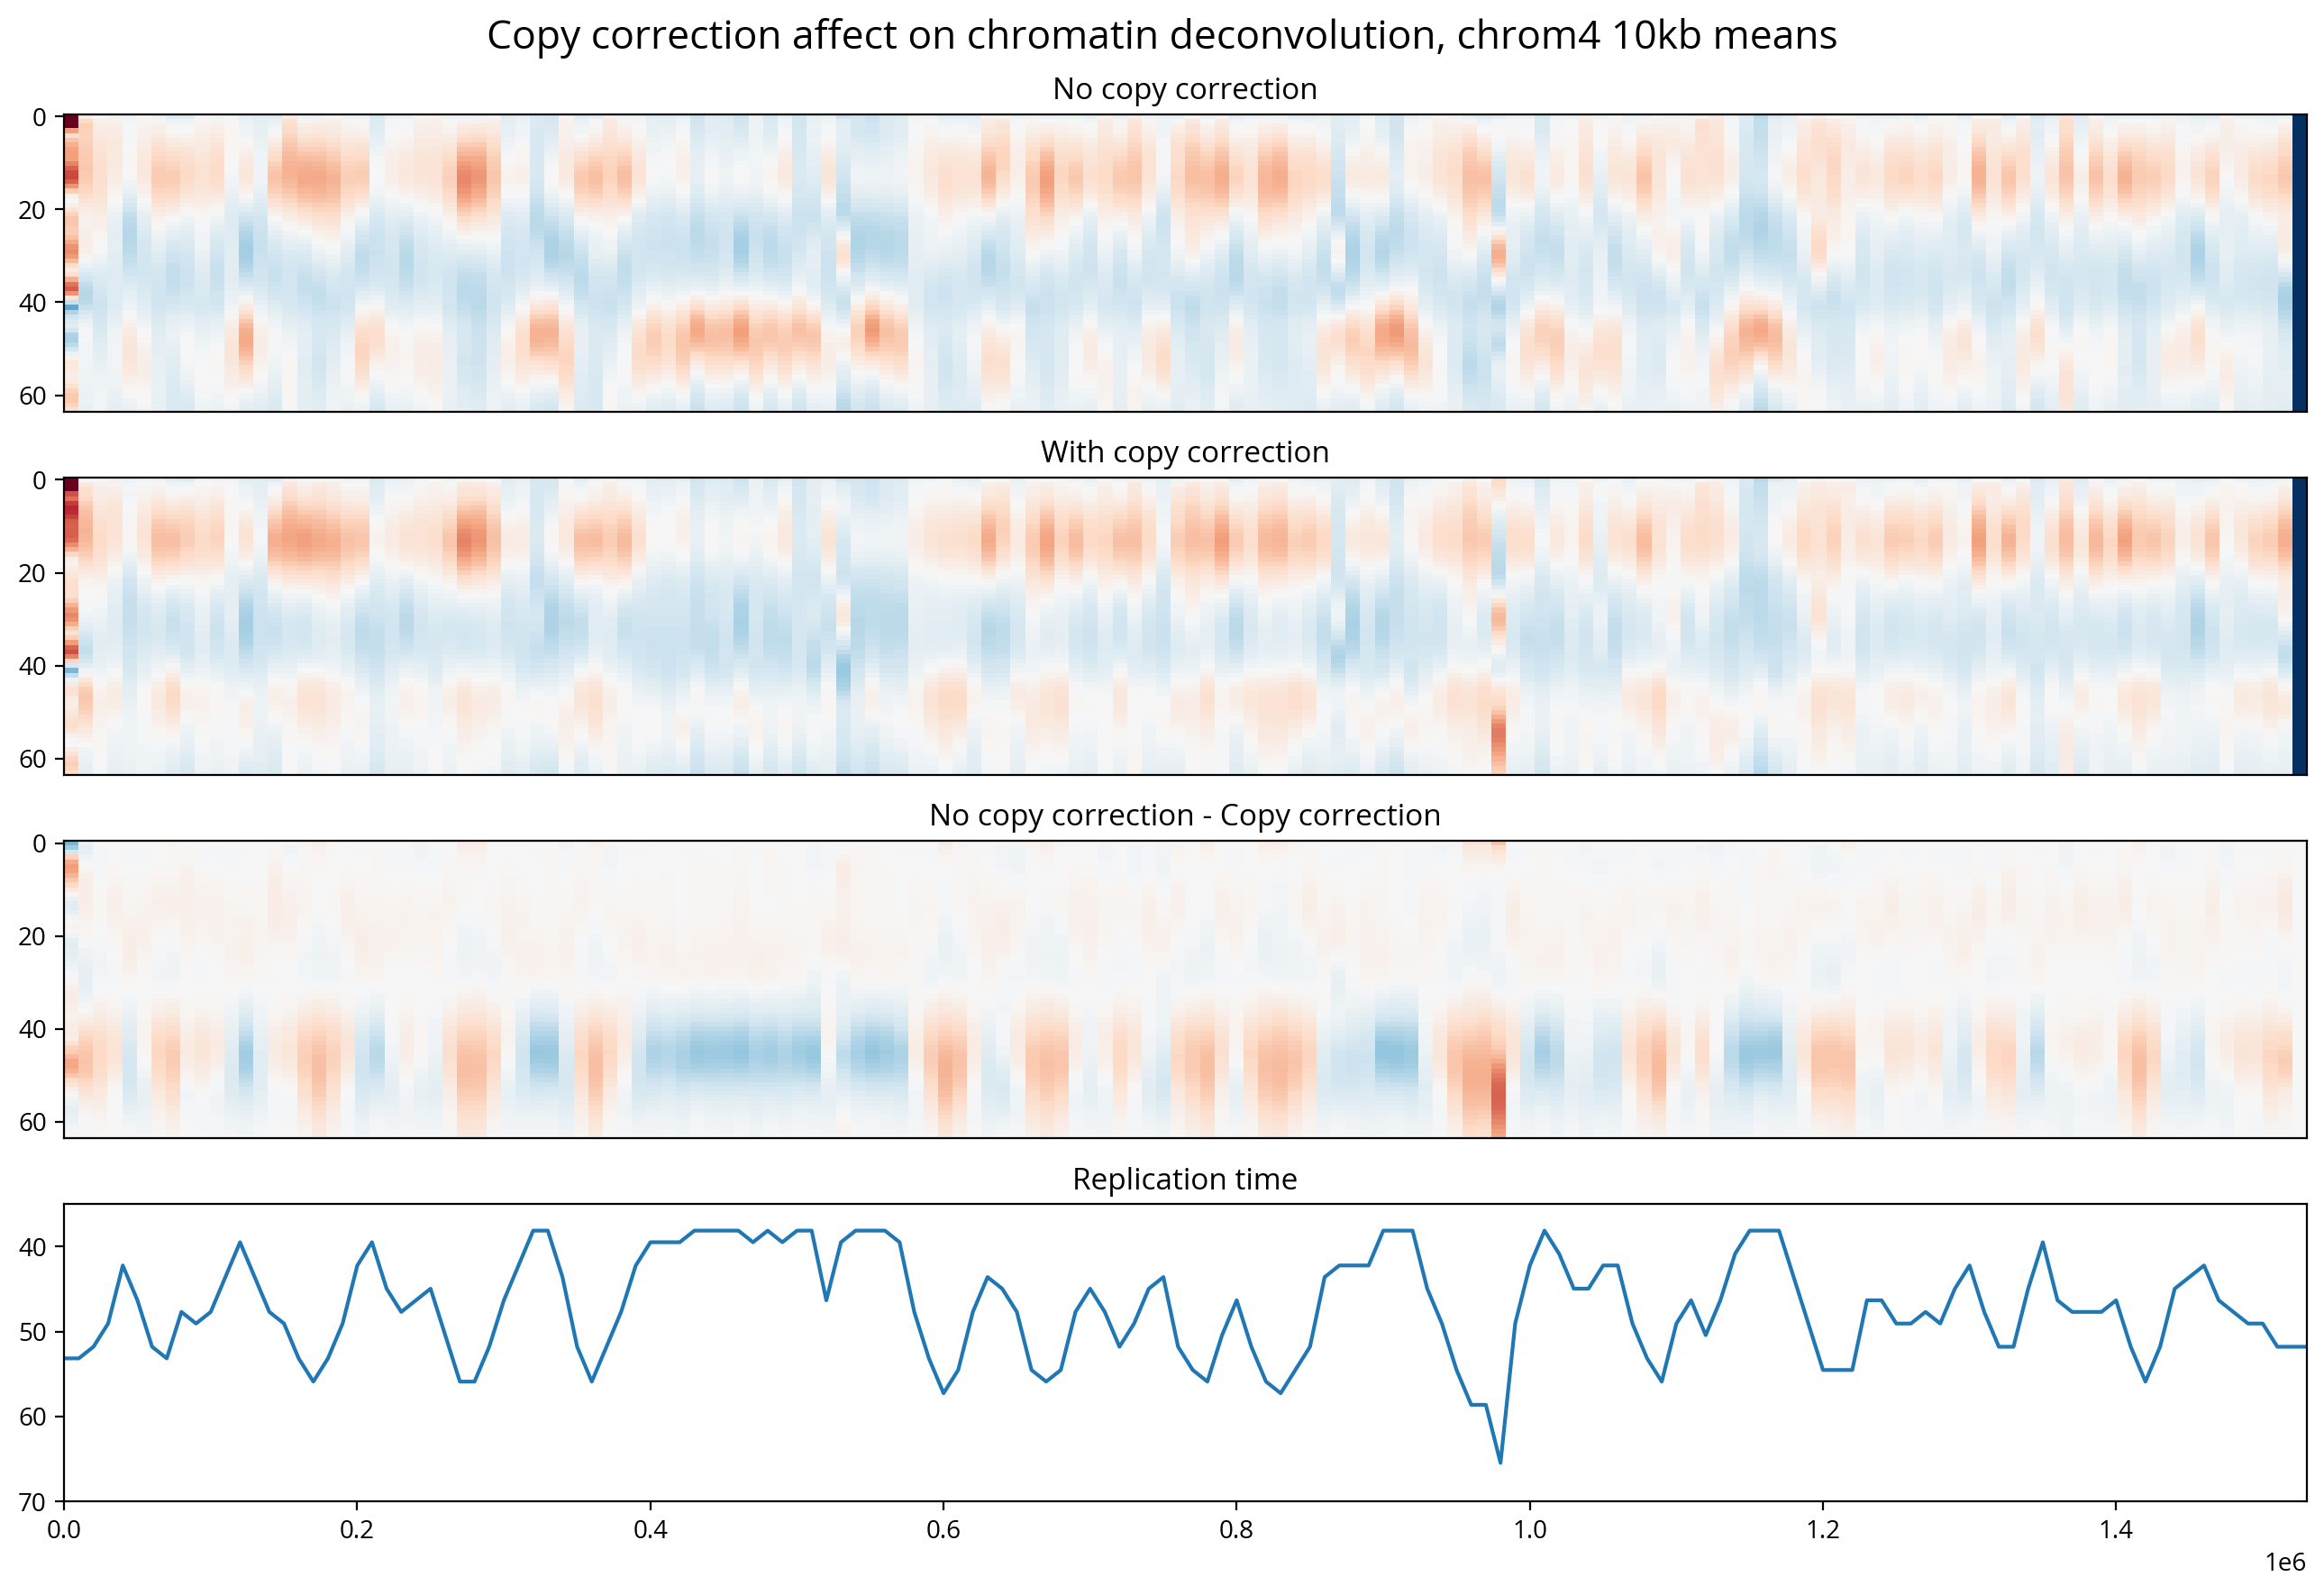

In [139]:
copy_correction_analysis.plot_heatmap_comparison()

In [138]:
copy_correction_analysis.compute_ptrs()

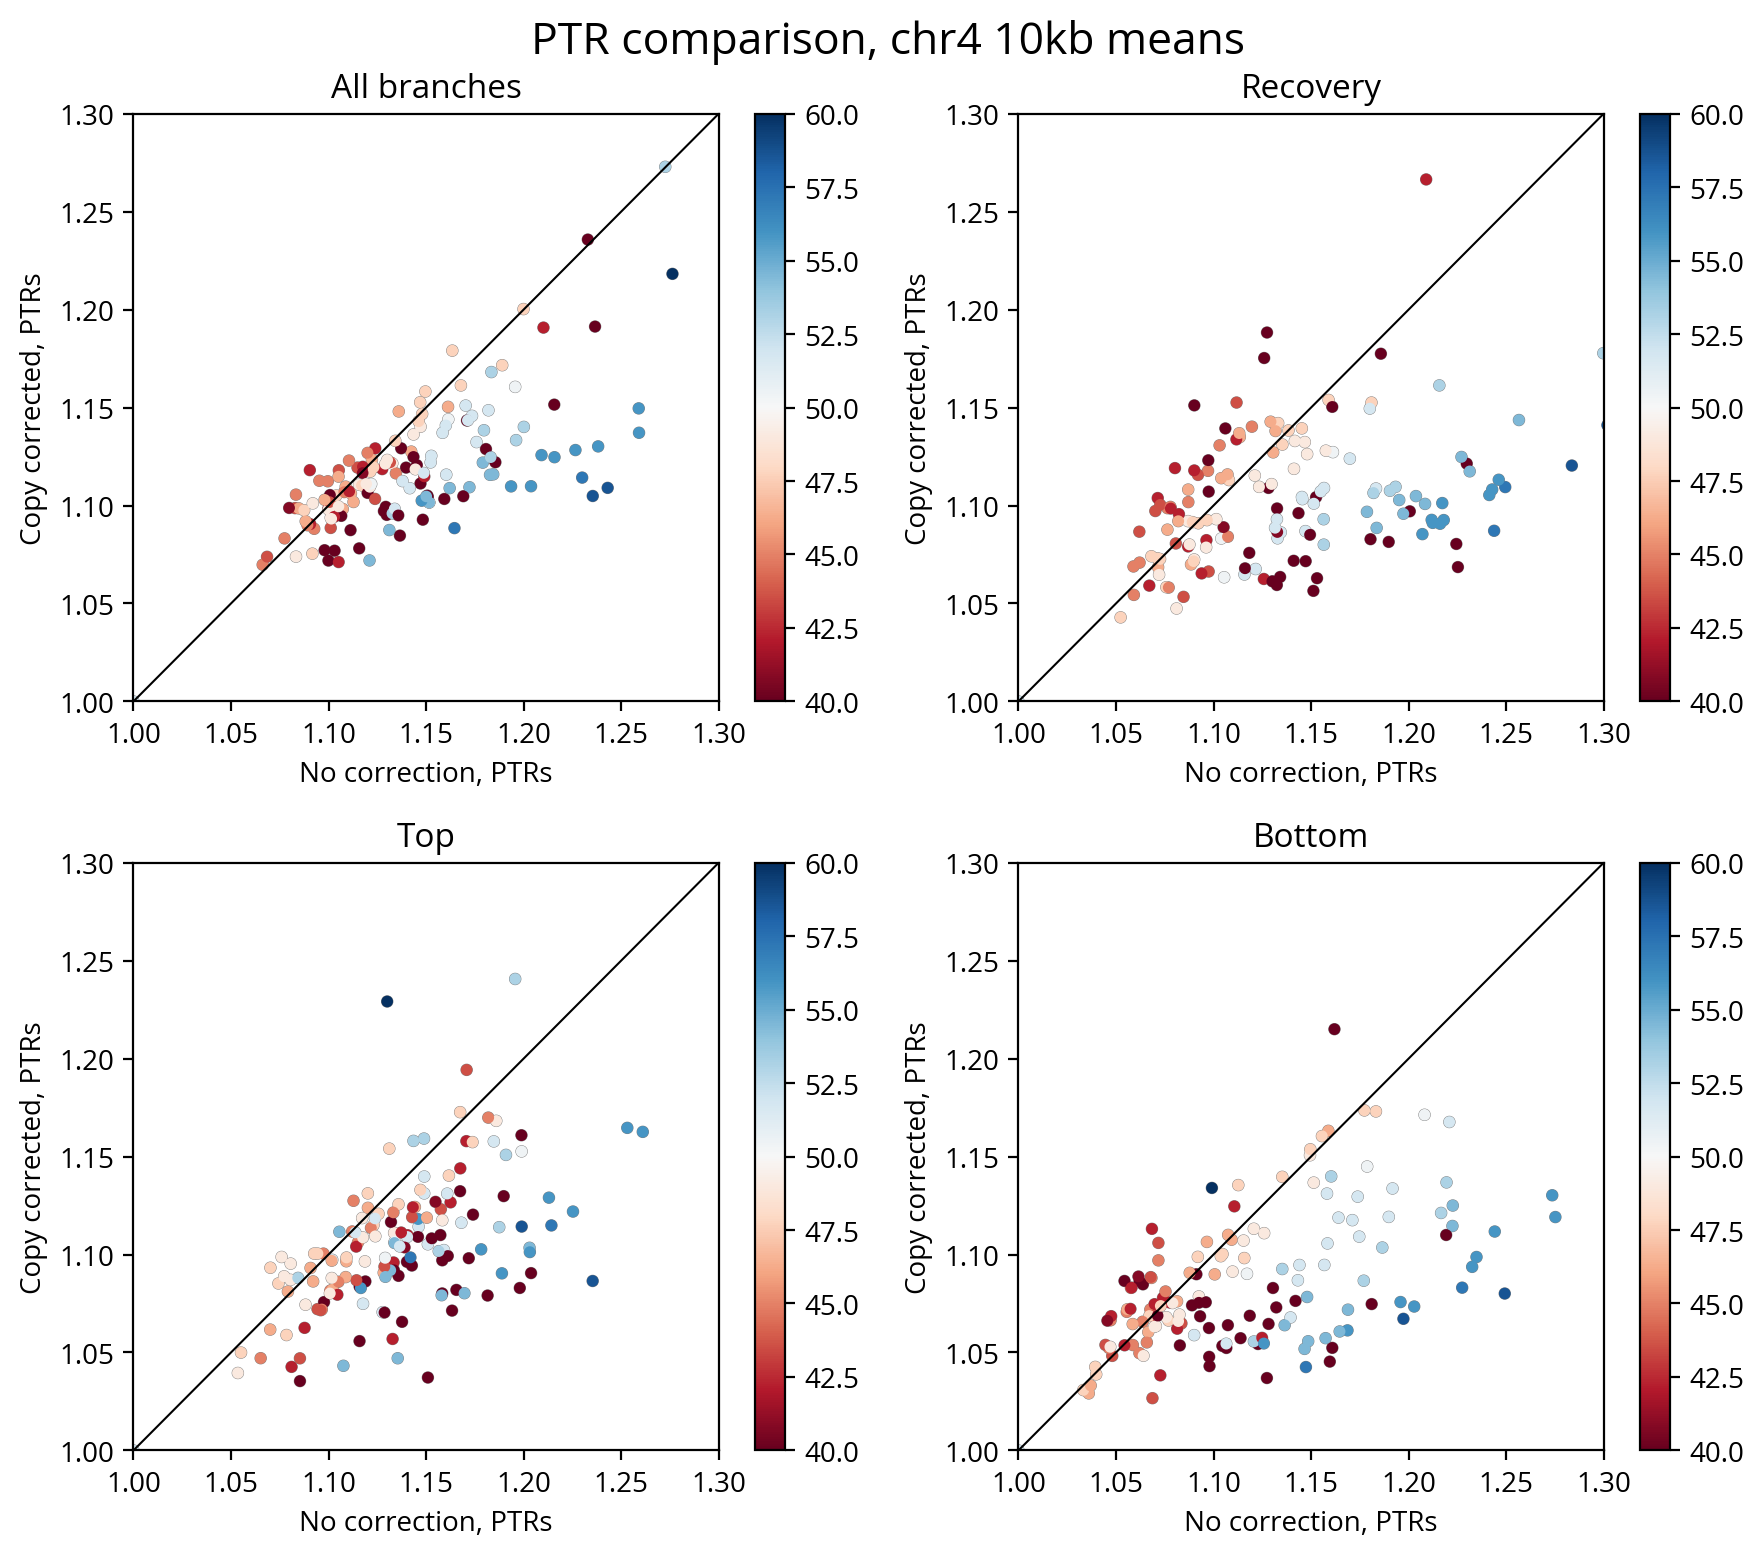

In [141]:
copy_correction_analysis.plot_branch_ptrs()

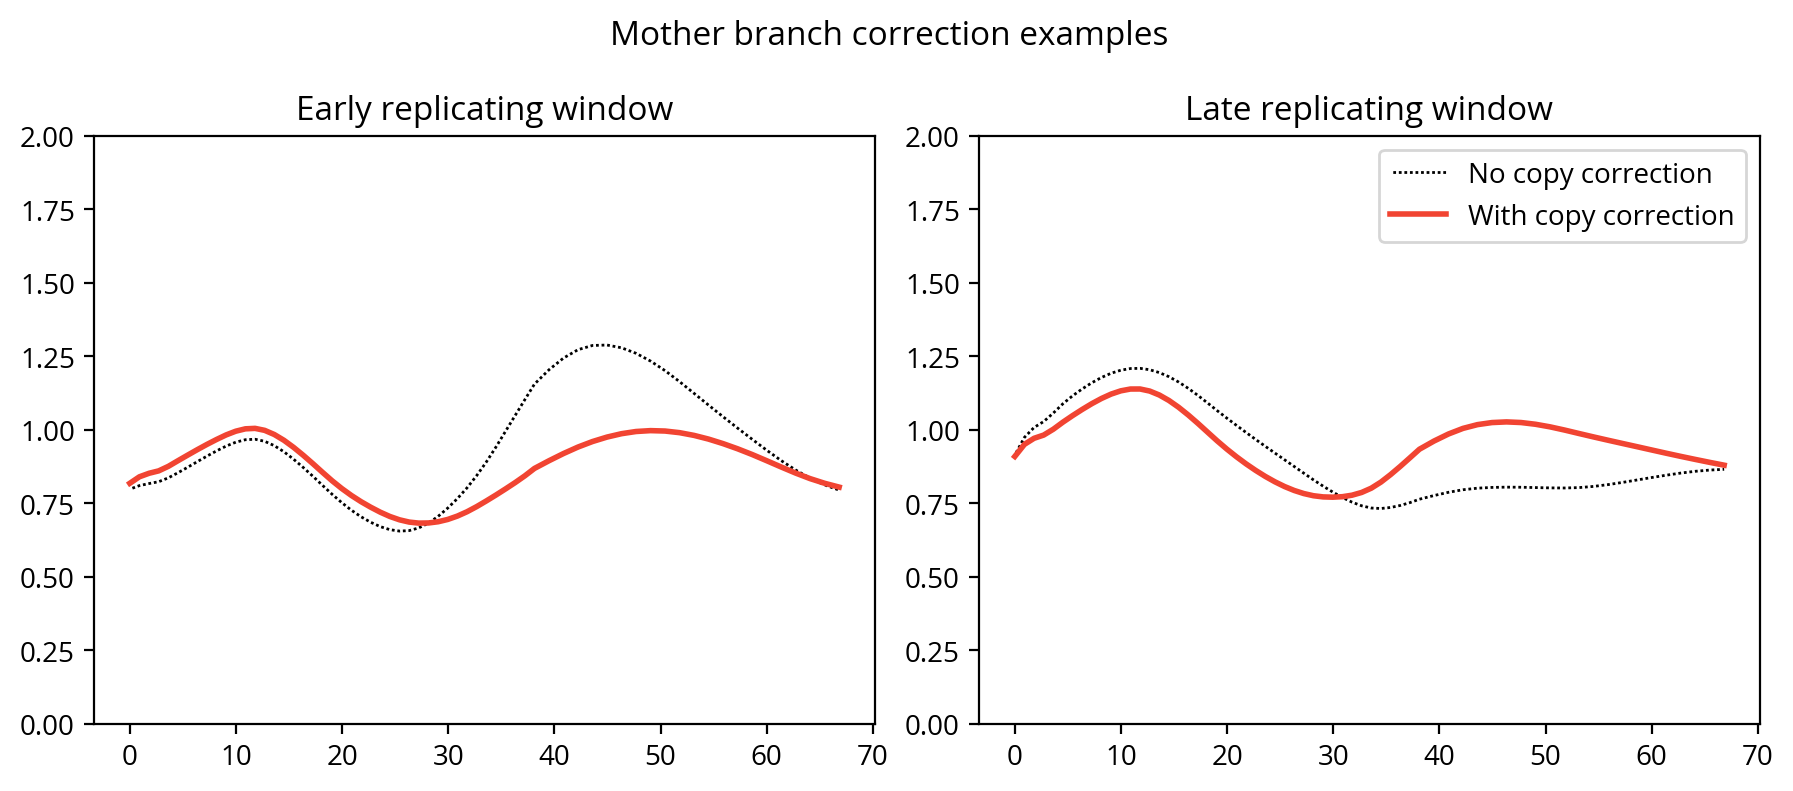

In [118]:
copy_correction_analysis.plot_sample_curves()